
Linear Regression
MSE: 19338.6598223879
R2: -9.737482624894156e-06

Random Forest
MSE: 19870.108303474524
R2: -0.027491148342426275

SVR
MSE: 20199.143139963704
R2: -0.04450566969406933

XGBoost
MSE: 19902.34471996004
R2: -0.029158106171103926
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001344 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 824
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 18
[LightGBM] [Info] Start training from score 259.445160

LightGBM
MSE: 19692.74971921056
R2: -0.018319865899949495


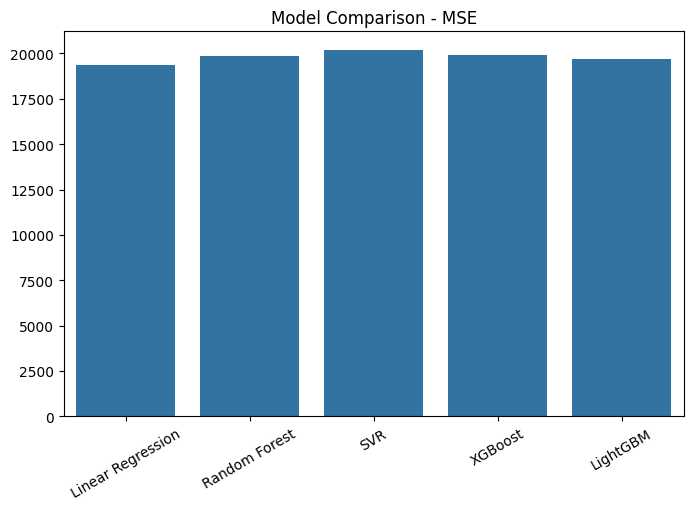

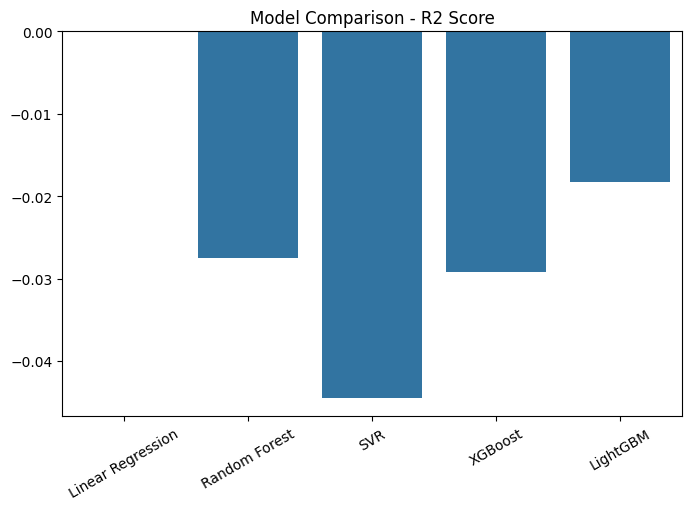


Best Model: Linear Regression
Confidence Interval: ± 272.5596756053243


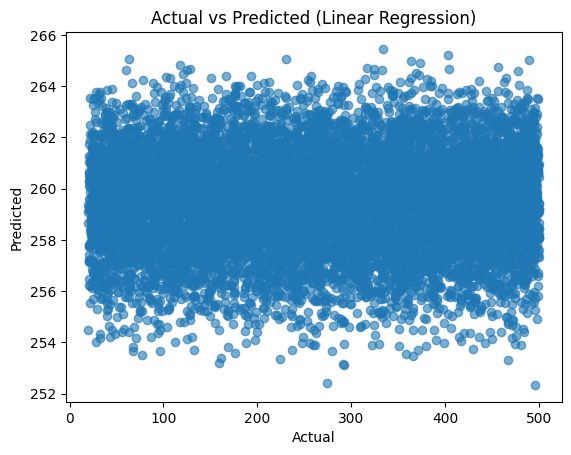

In [4]:
# =========================
# Import Libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor



# =========================
# Load Dataset
# =========================
df = pd.read_csv('/content/House_Price_Prediction_Dataset_50000.csv')

# =========================
# Handle Missing Values
# =========================
df = df.dropna()

# =========================
# Encode Categorical Data
# =========================
df = pd.get_dummies(df, drop_first=True)

# =========================
# Split Features & Target
# =========================

target_column = 'Price_Lakhs'

X = df.drop('Price_Lakhs', axis=1)
y = df['Price_Lakhs']

# =========================
# Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

# =========================
# Feature Scaling (for SVR)
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# =========================
# Models
# =========================
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "SVR": SVR(C=100),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.1),
    "LightGBM": LGBMRegressor(n_estimators=200)
}

# =========================
# Training & Evaluation
# =========================
results = {}

for name, model in models.items():

    if name == "SVR":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = (model, mse, r2)

    print(f"\n{name}")
    print("MSE:", mse)
    print("R2:", r2)

# =========================
# Visualization
# =========================
model_names = list(results.keys())
mse_values = [results[m][1] for m in model_names]
r2_values = [results[m][2] for m in model_names]

plt.figure(figsize=(8,5))
sns.barplot(x=model_names, y=mse_values)
plt.title("Model Comparison - MSE")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x=model_names, y=r2_values)
plt.title("Model Comparison - R2 Score")
plt.xticks(rotation=30)
plt.show()

# =========================
# Best Model
# =========================
best_model_name = max(results, key=lambda x: results[x][2])
best_model = results[best_model_name][0]

print("\nBest Model:", best_model_name)

# =========================
# Confidence Interval 🔥
# =========================
if best_model_name == "SVR":
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

errors = y_test - y_pred_best
std_dev = np.std(errors)

print("Confidence Interval: ±", 1.96 * std_dev)

# =========================
# Actual vs Predicted
# =========================
plt.figure()
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.show()

# =========================
# Feature Importance 🔥
# =========================
if best_model_name in ["Random Forest", "XGBoost", "LightGBM"]:
    importances = best_model.feature_importances_
    features = X.columns

    feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

    plt.figure(figsize=(10,5))
    sns.barplot(x=feat_imp.values[:10], y=feat_imp.index[:10])
    plt.title("Top Features")
    plt.show()
